# Running The Cannon on APOGEE spectra — end to end

This notebook walks through the full APOGEE workflow using the high-level
`thecannon.apogee` API:

1. **Read** APOGEE spectra (`apStar` / `aspcapStar` FITS files).
2. **Process** them — pseudo-continuum-normalize on the standard APOGEE grid.
3. **Fit** them against a trained Cannon model to recover stellar labels
   (`TEFF`, `LOGG`, `FE_H`, ...).

The `thecannon.apogee` module supplies the APOGEE-specific glue:

| function | what it does |
|---|---|
| `apogee.wavelength_grid()` | the standard 8575-pixel log-linear dispersion |
| `apogee.continuum_pixel_mask()` | the canonical continuum-pixel mask |
| `apogee.read_spectrum()` / `read_spectra()` | read `apStar` / `aspcapStar` FITS |
| `apogee.normalize()` | per-chip pseudo-continuum normalization |
| `apogee.process()` | read + normalize in one call |
| `apogee.fit()` | read + normalize + run the test step against a model |
| `apogee.make_example_spectrum()` | write a synthetic file so this runs offline |

> **Real data.** Every step below works on real `apStar`/`aspcapStar` files —
> just pass their paths to `read_spectra` / `process` / `fit`. So the notebook
> runs anywhere, we *synthesize* APOGEE-format files here; the cell that does so
> is clearly marked, and the "point at real files" pattern is shown at the end.

In [1]:
# JAX must be configured before it is imported. The Cannon's test step runs
# on whatever device JAX picks; CPU is the safe default for a laptop demo.
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

# Make sure the working-tree copy of thecannon is importable when running from
# the notebooks/ directory of a source checkout.
import sys
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import thecannon as tc
from thecannon import apogee

print("thecannon:", tc.__version__, "->", tc.__file__)

thecannon: 0.2.93 -> /Users/mjablons/code/AnniesLasso/thecannon/__init__.py


## 1. The APOGEE wavelength grid and continuum pixels

Combined APOGEE spectra live on a fixed log-linear grid of 8575 pixels spanning
the three (blue / green / red) detectors. The Cannon normalizes each detector
independently — those spans are `apogee.DEFAULT_REGIONS`. A curated set of
roughly line-free **continuum pixels** anchors the pseudo-continuum fit.

grid: 8575 pixels, 15100.8 - 16999.8 Angstrom
continuum pixels: 672
detector regions (Angstrom):
  15090 - 15822
  15823 - 16451
  16452 - 16971


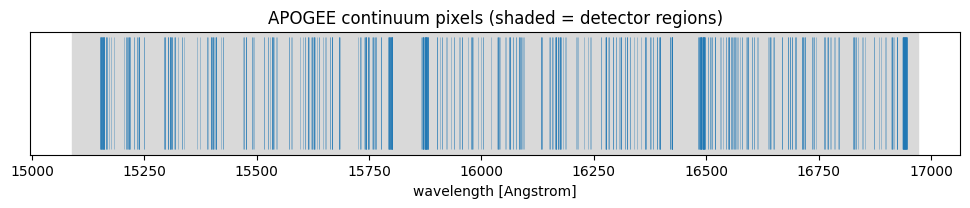

In [2]:
dispersion = apogee.wavelength_grid()
continuum_mask = apogee.continuum_pixel_mask(dispersion)

print(f"grid: {dispersion.size} pixels, {dispersion[0]:.1f} - {dispersion[-1]:.1f} Angstrom")
print(f"continuum pixels: {continuum_mask.sum()}")
print("detector regions (Angstrom):")
for lo, hi in apogee.DEFAULT_REGIONS:
    print(f"  {lo:.0f} - {hi:.0f}")

fig, ax = plt.subplots(figsize=(12, 1.6))
ax.vlines(dispersion[continuum_mask], 0, 1, color="C0", lw=0.4, alpha=0.6)
for lo, hi in apogee.DEFAULT_REGIONS:
    ax.axvspan(lo, hi, color="0.85", zorder=0)
ax.set(xlabel="wavelength [Angstrom]", yticks=[], title="APOGEE continuum pixels (shaded = detector regions)")
plt.show()

## 2. Read an APOGEE spectrum

`apogee.read_spectrum(path)` reads a single `apStar` or `aspcapStar` FITS file
and returns `(dispersion, flux, ivar)`. It reads the wavelength solution from
the file's WCS header and turns the 1-sigma uncertainty HDU into an inverse
variance (with `ivar = 0` for bad/zero-error pixels).

**Synthetic file (demo only).** Here we write an `apStar`-format file so the
notebook is self-contained. Replace this with your own paths to use real data.

read: (8575,) (8575,) (8575,)


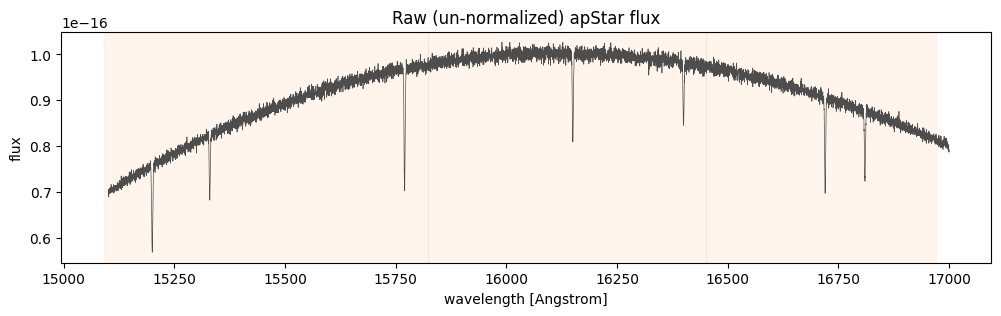

In [3]:
# --- demo data: write a synthetic apStar-format FITS file ---------------------
demo_path = "apStar-demo.fits"
apogee.make_example_spectrum(demo_path, teff=4800, logg=2.5, fe_h=-0.2, snr=120, seed=42)

# --- the part you would do with real data ------------------------------------
disp, flux, ivar = apogee.read_spectrum(demo_path)
print("read:", disp.shape, flux.shape, ivar.shape)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(disp, flux, lw=0.5, color="0.3")
for lo, hi in apogee.DEFAULT_REGIONS:
    ax.axvspan(lo, hi, color="C1", alpha=0.07, zorder=0)
ax.set(xlabel="wavelength [Angstrom]", ylabel="flux",
       title="Raw (un-normalized) apStar flux")
plt.show()

## 3. Pseudo-continuum normalization

`apogee.normalize()` wraps `thecannon.continuum.normalize()` with the APOGEE
continuum pixels and per-detector regions filled in. It fits a sum of sines and
cosines through the continuum pixels of each detector and divides it out,
returning `(normalized_flux, normalized_ivar, continuum, metadata)`.

(The warning about pixels outside the detector regions is expected: a few pixels
at the grid edges fall outside the standard APOGEE spans and are left as-is.)

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

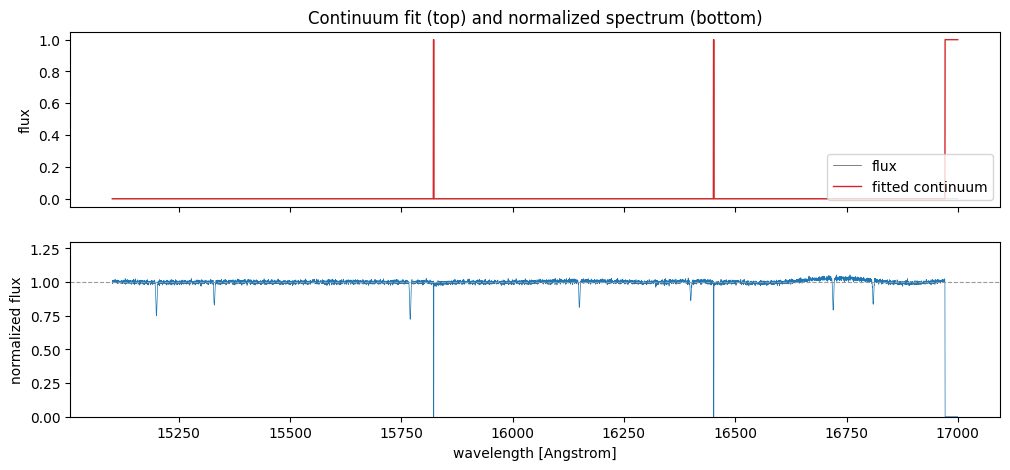

In [4]:
norm_flux, norm_ivar, continuum, meta = apogee.normalize(disp, flux, ivar)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(disp, flux, lw=0.5, color="0.3", label="flux")
axes[0].plot(disp, continuum, lw=1.0, color="C3", label="fitted continuum")
axes[0].legend(loc="lower right"); axes[0].set(ylabel="flux")
axes[1].plot(disp, norm_flux, lw=0.5, color="C0")
axes[1].axhline(1.0, color="0.6", lw=0.8, ls="--")
axes[1].set(xlabel="wavelength [Angstrom]", ylabel="normalized flux", ylim=(0, 1.3))
axes[0].set_title("Continuum fit (top) and normalized spectrum (bottom)")
plt.show()

## 4. A trained Cannon model

Fitting needs a **trained** model. In production you would load one that was
trained on a labelled reference sample:

```python
model = tc.CannonModel.read("apogee_dr17.model")
```

For this self-contained demo we train a small 3-label quadratic model on a
synthetic reference set built on the APOGEE grid. The label container can be any
mapping keyed by label name — a `pandas.DataFrame`, a dict of arrays, or an
`astropy` table.

In [5]:
# Build a small synthetic reference set spanning a slice of label space.
rng = np.random.default_rng(0)
N = 36
ref = pd.DataFrame({
    "TEFF": rng.uniform(4200, 5200, N),
    "LOGG": rng.uniform(1.8, 3.2, N),
    "FE_H": rng.uniform(-0.8, 0.3, N),
})

ref_paths = []
for k, row in ref.iterrows():
    p = f"apStar-ref-{k:02d}.fits"
    apogee.make_example_spectrum(p, teff=row.TEFF, logg=row.LOGG, fe_h=row.FE_H,
                                 snr=200, seed=1000 + k)
    ref_paths.append(p)

# Read + normalize the whole reference set in one call.
ref_disp, ref_flux, ref_ivar = apogee.process(ref_paths)
print("reference flux/ivar:", ref_flux.shape, ref_ivar.shape)

vectorizer = tc.vectorizer.PolynomialVectorizer(("TEFF", "LOGG", "FE_H"), 2)
model = tc.CannonModel(ref, ref_flux, ref_ivar, vectorizer=vectorizer,
                       dispersion=ref_disp)
model.train()
print(model)

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

2026-06-10 10:33:50,079 [INFO] Training 3-label CannonModel with 36 stars and 8575 pixels/star
INFO:thecannon.model:Training 3-label CannonModel with 36 stars and 8575 pixels/star


reference flux/ivar: (36, 8575) (36, 8575)


Training:   0%|          | 0/17 [00:00<?, ?it/s]

<thecannon.model.CannonModel of 3 labels trained with a training set of 36 stars each with 8575 pixels>


## 5. Fit spectra — the one-call pipeline

`apogee.fit(model, paths)` runs the whole chain: read the files, normalize
them, and run the model's test step. With `as_table=True` it also returns a
tidy `pandas.DataFrame` of the recovered labels plus the reduced chi-squared.

In [6]:
# A handful of held-out test stars with known labels.
truth = pd.DataFrame({
    "TEFF": [4500, 4800, 5000],
    "LOGG": [2.0, 2.5, 3.0],
    "FE_H": [-0.5, -0.2, 0.0],
})
test_paths = []
for k, row in truth.iterrows():
    p = f"apStar-test-{k}.fits"
    apogee.make_example_spectrum(p, teff=row.TEFF, logg=row.LOGG, fe_h=row.FE_H,
                                 snr=150, seed=9000 + k)
    test_paths.append(p)

labels, cov, fit_meta, recovered = apogee.fit(model, test_paths, as_table=True)

compare = recovered.copy()
for c in ("TEFF", "LOGG", "FE_H"):
    compare[c + "_true"] = truth[c].values
compare = compare[["TEFF", "TEFF_true", "LOGG", "LOGG_true",
                   "FE_H", "FE_H_true", "r_chi_sq"]]
compare.round(2)

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

Testing:   0%|          | 0/3 [00:00<?, ?it/s]

,TEFF,TEFF_true,LOGG,LOGG_true,FE_H,FE_H_true,r_chi_sq
0,4842.24,4500,2.00,2.0,-0.44,-0.5,1.24
1,4962.44,4800,2.50,2.5,-0.18,-0.2,1.12
2,4705.48,5000,2.99,3.0,-0.06,0.0,1.17


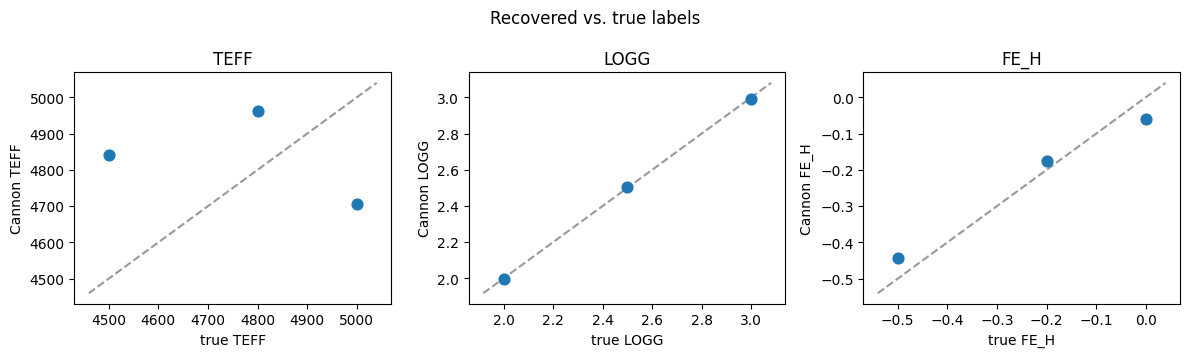

In [7]:
# Recovered vs. true labels.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, name in zip(axes, ("TEFF", "LOGG", "FE_H")):
    ax.scatter(truth[name], recovered[name], s=60, color="C0", zorder=3)
    lo = min(truth[name].min(), recovered[name].min())
    hi = max(truth[name].max(), recovered[name].max())
    pad = 0.08 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "0.6", ls="--")
    ax.set(xlabel=f"true {name}", ylabel=f"Cannon {name}", title=name)
fig.suptitle("Recovered vs. true labels")
fig.tight_layout()
plt.show()

## 6. Using real data

Everything above is identical for real `apStar` / `aspcapStar` files — only the
paths change. Download files from the SDSS Science Archive Server and point the
same calls at them:

```python
# Fit a single star and get a labelled table back:
labels, cov, meta, table = apogee.fit(
    model, "aspcapStar-dr17-2M19281121+4445359.fits", as_table=True)

# Or process many files (read + normalize) for your own downstream use:
disp, flux, ivar = apogee.process(sorted(glob.glob("data/apStar-*.fits")))
labels, cov, meta = model.test(flux, ivar)
```

Useful knobs:

- `apogee.read_spectrum(path, row=...)` — for multi-row `apStar` HDUs, pick which
  combined/visit spectrum to read (row 0 is the pixel-weighted combination).
- `apogee.normalize(..., continuum_pixels=mask)` — supply your own continuum mask
  (boolean or integer indices), e.g. a censored list for a particular element.
- `apogee.fit(model, paths, initial_labels=...)` — seed the optimizer with prior
  label estimates for faster / more robust convergence.

### Summary

`thecannon.apogee` turns the three-step APOGEE workflow — *read → normalize →
fit* — into a couple of calls (`apogee.process` and `apogee.fit`) on top of the
data-agnostic Cannon core, while still exposing every intermediate array for
inspection.